In [162]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [163]:
path = 'data/Mall_Customers.csv'

In [164]:
df = pd.read_csv(path)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


- Gender: Giới tính
- Age: Độ tuổi
- Annual Income: thu thập hàng năm
- Spending Score: Điểm chi tiêu

In [165]:
df = df.drop(["CustomerID"], axis=1)

### EDA

In [166]:
print("Số lượng giá trị thiếu trong từng cột:")
print(df.isnull().sum())

Số lượng giá trị thiếu trong từng cột:
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


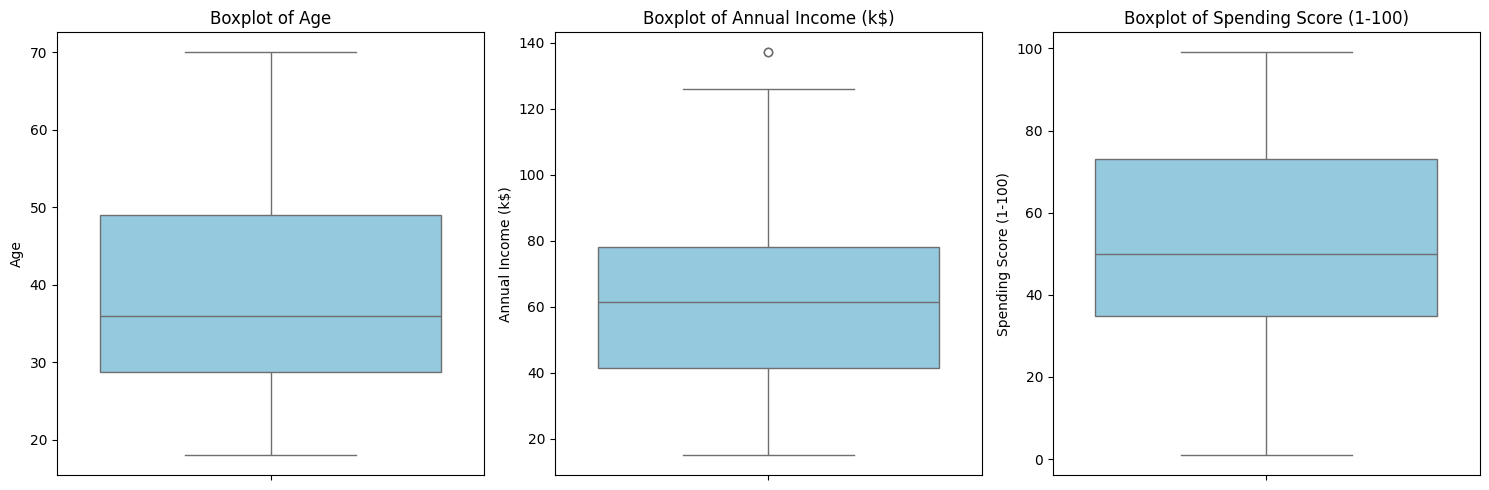

In [167]:
plt.figure(figsize=(15, 5))

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

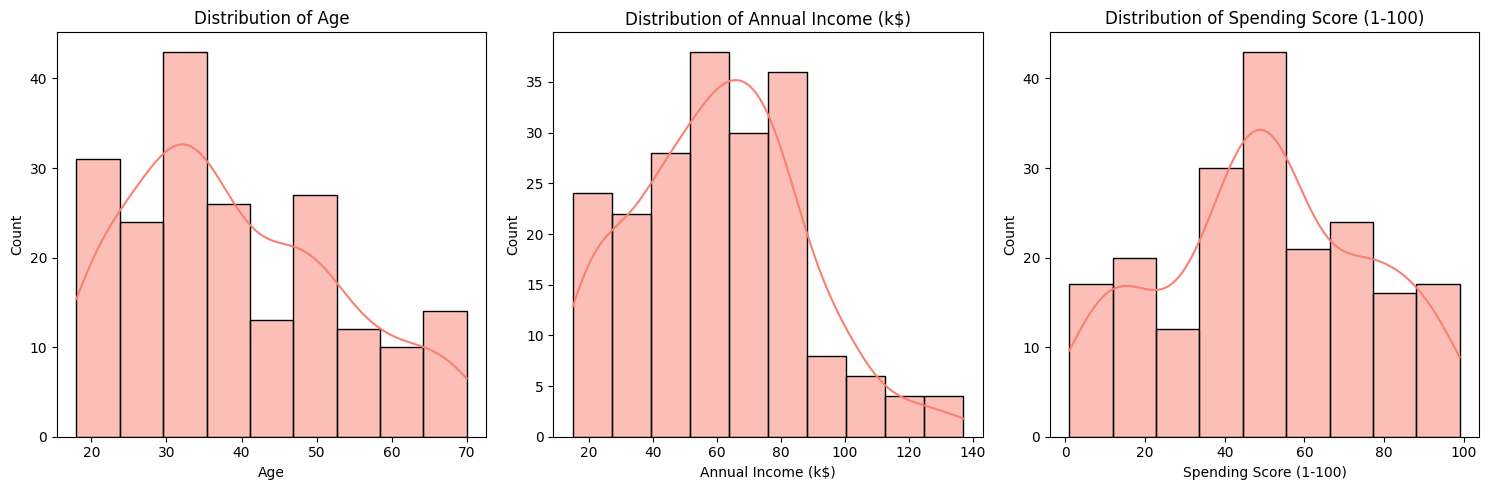

In [168]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='salmon')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [169]:
print("Thống kê mô tả dữ liệu:")
print(df[features].describe().round(2))

Thống kê mô tả dữ liệu:
          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean    38.85               60.56                   50.20
std     13.97               26.26                   25.82
min     18.00               15.00                    1.00
25%     28.75               41.50                   34.75
50%     36.00               61.50                   50.00
75%     49.00               78.00                   73.00
max     70.00              137.00                   99.00


### Data clearn

In [170]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(200, 4)

### Data Processing

In [171]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        
    def fit(self, X):
        X_array = np.asarray(X)
        # Tính trung bình và độ lệch chuẩn theo từng cột
        self.mean_ = np.mean(X_array, axis=0)
        self.std_ = np.std(X_array, axis=0)
        # Tránh lỗi khi chia cho 0
        self.std_[self.std_==0] = 1e-9
        return self
        
    def transform(self, X):
        X_array = np.asarray(X)
        # Áp dụng công thức: (X - mean) / std
        return (X_array - self.mean_) / self.std_
         
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [ ]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [172]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']

scaler = MyStandardScaler()
df[features] = scaler.fit_transform(df[features])

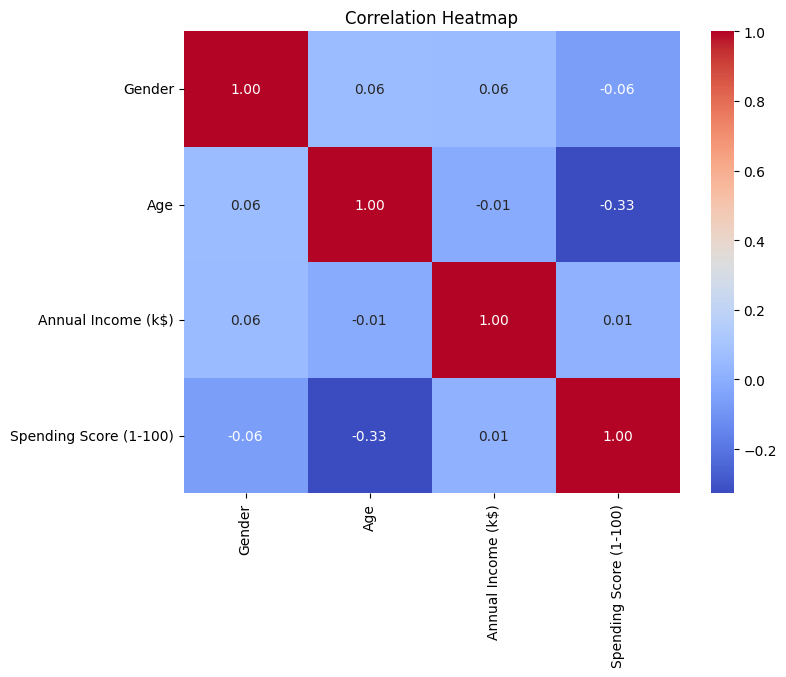

In [174]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [175]:
X = df[features].values

In [176]:
class KMeansScratch:
    def __init__(self, k=5, max_iters=100, tolerance=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tolerance = tolerance
        self.centroids = None
        self.inertia_ = 0 # Để tính Elbow

    def fit(self, X):
        # 1. Khởi tạo Centroids ngẫu nhiên từ tập dữ liệu
        random_indices = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iters):
            # 2. Gán cụm: Tính khoảng cách Euclidean từ mỗi điểm đến các Centroids
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)

            # Lưu centroids cũ để kiểm tra điều kiện dừng
            old_centroids = self.centroids.copy()

            # 3. Cập nhật Centroids: Lấy trung bình cộng các điểm trong cụm
            for idx in range(self.k):
                cluster_points = X[self.labels == idx]
                if len(cluster_points) > 0:
                    self.centroids[idx] = cluster_points.mean(axis=0)

            # 4. Kiểm tra điều kiện dừng (nếu centroids không đổi đáng kể)
            if np.all(np.abs(self.centroids - old_centroids) < self.tolerance):
                break
        
        # Tính Inertia (WCSS) để dùng cho Elbow Method
        self.inertia_ = 0
        for idx in range(self.k):
            cluster_points = X[self.labels == idx]
            if len(cluster_points) > 0:
                self.inertia_ += np.sum(np.square(cluster_points - self.centroids[idx]))

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

In [177]:
model = KMeansScratch(k=5, max_iters=300)
model.fit(X)
labels = model.labels

df['Cluster_custom'] = labels

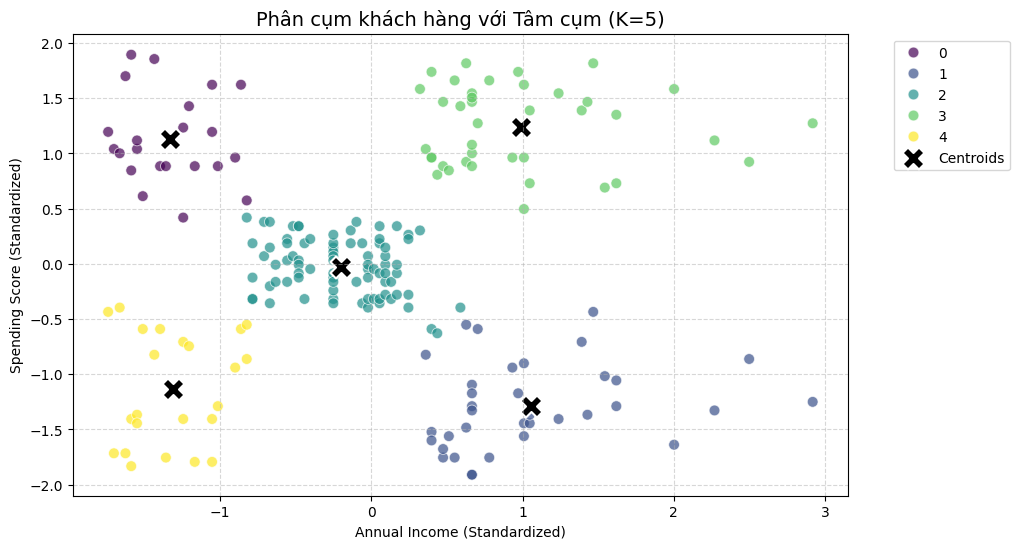

In [178]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster_custom'],
    palette='viridis',
    s=60,
    alpha=0.7
)

plt.scatter(
    model.centroids[:, 0], 
    model.centroids[:, 1], 
    s=250,           # Kích thước lớn để nổi bật
    c='black',       # Màu đen
    marker='X',      # Dấu X
    edgecolors='white', 
    linewidths=1.5,
    label='Centroids'
)

plt.title('Phân cụm khách hàng với Tâm cụm (K=5)', fontsize=14)
plt.xlabel('Annual Income (Standardized)')
plt.ylabel('Spending Score (Standardized)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Đẩy chú thích ra ngoài nếu bị đè
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [179]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

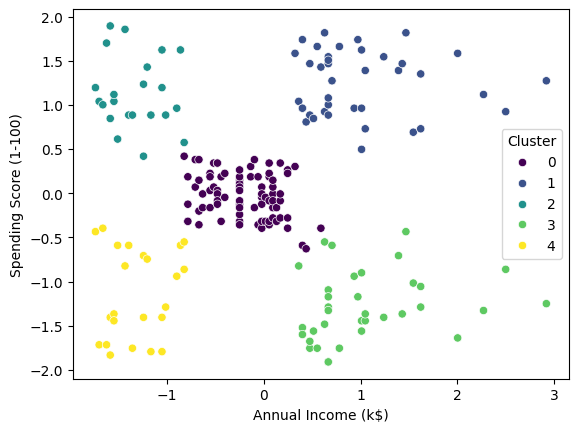

In [180]:
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

In [181]:
def silhouette_score_scratch(X, labels):
    n = len(X)
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2: return 0
    
    scores = []
    for i in range(n):
        # a(i): Khoảng cách trung bình đến các điểm cùng cụm
        same_cluster = X[labels == labels[i]]
        if len(same_cluster) > 1:
            a = np.mean(np.linalg.norm(same_cluster - X[i], axis=1)) * (len(same_cluster) / (len(same_cluster) - 1))
        else:
            a = 0
            
        # b(i): Khoảng cách trung bình đến các điểm ở cụm gần nhất khác
        b = float('inf')
        for label in unique_labels:
            if label == labels[i]: continue
            other_cluster = X[labels == label]
            avg_dist_other = np.mean(np.linalg.norm(other_cluster - X[i], axis=1))
            b = min(b, avg_dist_other)
            
        # Tính s(i)
        s = (b - a) / max(a, b) if max(a, b) > 0 else 0
        scores.append(s)
        
    return np.mean(scores)

In [182]:
# Lấy labels và centroids từ mô hình
labels = model.labels
centroids = model.centroids

# Tính toán các chỉ số
s_score = silhouette_score_scratch(X, labels)

print(f"--- BÁO CÁO PHÂN CỤM (FROM SCRATCH) ---")
print(f"Silhouette Score (Gần 1 là tốt): {s_score:.4f}")

--- BÁO CÁO PHÂN CỤM (FROM SCRATCH) ---
Silhouette Score (Gần 1 là tốt): 0.5547
